In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(torch.__version__)

2.5.1


In [2]:
## GPU check 
!nvidia-smi

Sun Dec  7 08:19:07 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.97                 Driver Version: 555.97         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650 Ti   WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   54C    P0             16W /   50W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Introduction to tensors

### Creating tensors

In [3]:
# scalar
scalar=torch.tensor(26)
scalar

tensor(26)

In [4]:
scalar.ndim

0

In [5]:
# Get tensor back to the Python int
scalar.item()

26

In [6]:
#Vector
vector= torch.tensor([2,3])
vector

tensor([2, 3])

In [7]:
vector.ndim

1

In [8]:
vector.shape


torch.Size([2])

In [10]:
# MATRIX
MATRIX = torch.tensor([[5,6],
                      [7,8]])
MATRIX

tensor([[5, 6],
        [7, 8]])

In [11]:
MATRIX.ndim

2

In [12]:
MATRIX[0],MATRIX[1]

(tensor([5, 6]), tensor([7, 8]))

In [13]:
MATRIX.shape

torch.Size([2, 2])

In [14]:
# TENSOR
TENSOR = torch.tensor([[[2,3,3],
                        [4,3,2],
                        [3,6,4]]])

In [15]:
TENSOR.ndim

3

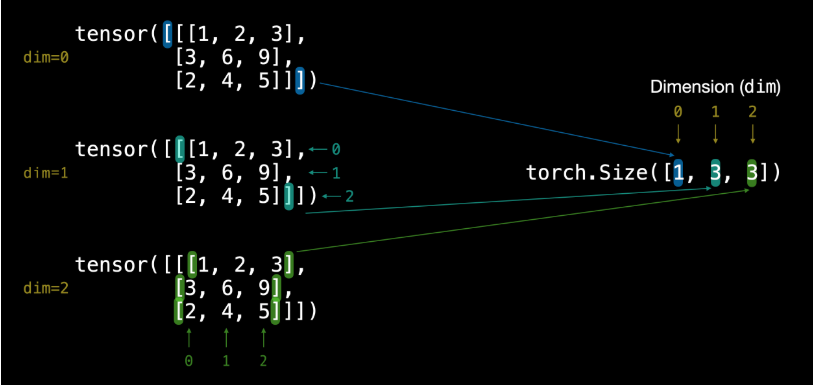

In [16]:
TENSOR.shape

torch.Size([1, 3, 3])

### Random tensors

Why random tensors?

Random tensors are important because the way many neural network learn is that thay start
with tensors full of random numbers and then adjust those random numbers to better represent the data

`Start with random numbers -> look at data -> update random numbers -> look at data -> update random numbers`

Torch random tensors - https://docs.pytorch.org/docs/stable/generated/torch.rand.html

In [24]:
# create a random tensor of size (3,4)
random_tensor = torch.rand(3,4)
random_tensor

tensor([[0.1644, 0.5372, 0.1366, 0.5135],
        [0.2832, 0.5690, 0.4967, 0.7995],
        [0.7779, 0.0841, 0.3052, 0.6442]])

In [25]:
random_tensor.ndim

2

In [26]:
random_tensor.shape

torch.Size([3, 4])

In [29]:
# create a random tensor with similar shape to an image tensor
random_image_size_tensor=torch.rand(size=(3,224,224)) # height, width, colour channels (R, G, B)
#random_image_size_tensor
random_image_size_tensor.ndim, random_image_size_tensor.shape

(3, torch.Size([3, 224, 224]))

### Zeros and ones

In [43]:
## Create a tensor of all zeros
zeros=torch.zeros(size=(3,4))
zeros,zeros.ndim

(tensor([[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]),
 2)

In [45]:
## Create a tensor of all ones
ones= torch.ones(size=(3,4))
ones

tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]])

In [46]:
ones.dtype

torch.float32

### Creating a range of tensors ans tensors like 

In [50]:
one_to_ten=torch.arange(0,10)
one_to_ten

tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [51]:
one_to_hundred_with_jump=torch.arange(start=0,end=100,step=10)
one_to_hundred_with_jump

tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [52]:
## Creating tensors like
ten_zeros=torch.zeros_like(input=one_to_ten)
ten_zeros

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

### Tensor datatype

**Notes:** Tensors datatypes is one of the 3 big errors you will run into PyTorch and deeplearning
1. Tensors are not right datatype
2. Tensors are not right shape
3. Tensors not on the right device

In [57]:
float_32_tensor=torch.tensor([3.0,6.0,9.0],
                             dtype=None, # what datatype is the tensor.
                             device=None, # what device is your tensor on
                             requires_grad=False) # whether or not to track gradients with this tensors operations

float_32_tensor

tensor([3., 6., 9.])

In [54]:
float_32_tensor.dtype

torch.float32

In [58]:
float_16_tensors = float_32_tensor.type(torch.half)

In [59]:
float_16_tensors.dtype

torch.float16

### Getting information from tensors

In [63]:
some_tensor=torch.rand(3,5) 
some_tensor

tensor([[0.8010, 0.9473, 0.7473, 0.5905, 0.7698],
        [0.5331, 0.9785, 0.6041, 0.8387, 0.4677],
        [0.1706, 0.9088, 0.4655, 0.2878, 0.9979]])

In [65]:
## Find out the details about the tensors
print(some_tensor)
print(f"Datatype of tensor: {some_tensor.dtype}")
print(f"Shape of tensor: {some_tensor.shape}")
print(f"Device tensor is on: {some_tensor.device}")


tensor([[0.8010, 0.9473, 0.7473, 0.5905, 0.7698],
        [0.5331, 0.9785, 0.6041, 0.8387, 0.4677],
        [0.1706, 0.9088, 0.4655, 0.2878, 0.9979]])
Datatype of tensor: torch.float32
Shape of tensor: torch.Size([3, 5])
Device tensor is on: cpu


### Manipulating tensors (tensors operations)

Tensor operations include 
* Addition
* Subtraction
* Multiplication (element-wise)
* Division
* matrix multiplication

In [ ]:
# Create a tensor and 10 to it 
tensor = torch.tensor([1,2,3])
tensor + 10

tensor([11, 12, 13])

In [67]:
#Multiply tensor by 10
tensor * 10

tensor([10, 20, 30])

In [68]:
# Subtract 10
tensor - 10

tensor([-9, -8, -7])

In [72]:
# Try out PyTorch in-built functions
torch.mul(tensor,10)

tensor([10, 20, 30])

In [73]:
torch.add(tensor,10)

tensor([11, 12, 13])

### Matrix multiplication

Two main way of performing multiplication in neural networks and deep learning.

1. Element-wise multiplication
2. Matrix multiplication (dot product)

In [76]:
# Element wise multiplication
tensor * tensor

tensor([1, 4, 9])

In [79]:
# Matrix multiplication
torch.matmul(tensor,tensor)

tensor(14)

In [81]:
%%time
value=0
for i in range(len(tensor)):
    value+= tensor[i] * tensor[i]
value

CPU times: total: 0 ns
Wall time: 13 ms


tensor(14)

In [83]:
%%time
torch.matmul(tensor,tensor)

CPU times: total: 0 ns
Wall time: 0 ns


tensor(14)

### One of the most common errors in deeplearning

In [ ]:
tensor_A=torch.tensor([[1,2],
                      [3,4],
                      [5,6]])
#tensor.ndim
tensor_B=torch.tensor([[7,10],
                      [8,11],
                      [9,12]])

In [ ]:
torch.mm(tensor_A,tensor_B) # we can use the torch.mm or torch.matmul

RuntimeError: mat1 and mat2 shapes cannot be multiplied (3x2 and 3x2)

To fix our tensor shapes issues, we can manipulate the shape of one of our tensor using **transpose**

The **transpose** switched the axes or dimensions of a given tensor

In [90]:
tensor_B.T

tensor([[ 7,  8,  9],
        [10, 11, 12]])

In [91]:
tensor_B

tensor([[ 7, 10],
        [ 8, 11],
        [ 9, 12]])

In [92]:
torch.matmul(tensor_A, tensor_B.T)

tensor([[ 27,  30,  33],
        [ 41,  46,  51],
        [ 95, 106, 117]])

In [95]:
torch.matmul(tensor_A, tensor_B.T).shape

torch.Size([3, 3])

### Find the min, max, mean, sum etc (tensor aggregation)

In [102]:
x = torch.arange(0,100,10)
x, x.dtype

(tensor([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]), torch.int64)

In [99]:
# Find the min
torch.min(x),x.min()

(tensor(0), tensor(0))

In [100]:
# Find the max
torch.max(x),x.max()

(tensor(90), tensor(90))

In [105]:
# Find the mean - note: the torch.mean() function required a tensor of float32 datatype to work
torch.mean(x.type(torch.float32)), x.type(torch.float32).mean()

(tensor(45.), tensor(45.))

In [107]:
# Find the sum
torch.sum(x), x.sum()

(tensor(450), tensor(450))

### Finding the positional min and max 

In [110]:
# Find the position in tensor that has the minimum value with argmin() -> return the index position
x.argmin()

tensor(0)

In [109]:
x[0]

tensor(0)

In [ ]:
# # Find the position in tensor that has the maximum value with argmax()
x.argmax()

tensor(9)

In [112]:
x[9]

tensor(90)